## 머신러닝이란? = 기계학습
데이터에서 **패턴을 발견**하고, 그 패턴을 바탕으로 **새로운 데이터를 예측**할 수 있도록 모델을 학습시키는 인공지능의 한 분야 

### 머신러닝의 종류

| | 정답 여부 | 방식 | 예시 |
|---|---|---|---|
| **지도학습** | 정답(label) 있음 | 예측값이 정답과 같아지도록 학습 | 회귀, 분류 |
| **비지도학습** | 정답 없음 | 데이터의 패턴/유사성을 학습 | 군집화 |
| **강화학습** | 보상 | 시행착오로 보상을 최대화하는 행동 학습 | 알파고, 자율주행 |

- **지도학습 예시**: 고양이/기린 사진에 "이건 고양이", "이건 기린"이라고 정답을 알려주며 학습
- **비지도학습 예시**: 정답 없이 사진들만 보여줘도, 노랗고 목이 긴 동물끼리 스스로 묶어내는 것

**(참고) 비지도학습 - 군집화**
- feature만 있고 target/label은 없는 데이터로 학습
- 유사도를 학습해 구조·패턴을 찾음 → 군집화(Clustering), 밀도추정(Density Estimation), 차원축소(Dimensionality Reduction)
- 활용 예: 이상탐지(anomaly detection), 고객세분화

## 모델링

- **모델**: 학습의 결과물, 데이터를 넣으면 답을 내놓는 예측기. 예: 공부시간 x → 시험점수 y를 내는 공식 `y = ax + b`도 모델
- **모델링**: 오차가 작은 최적의 공식을 찾아가는 전체 과정

**모델링의 과정**
1. 설계: 어떤 알고리즘으로 학습할지 결정
2. 훈련(Training): 데이터를 반복해서 보여주며 정답을 맞히도록 수정
3. 검증(Evaluation): 새로운 데이터에서도 잘 맞히는지 테스트

##  지도학습

**정답(label)을 함께 주고 학습시키는 방법.** 예측값(prediction)과 정답이 최대한 같아지도록 학습.

### 지도학습의 과정

1. **labeled data**: 독립변수(feature, 예측에 쓰이는 입력)와 종속변수(target/label, 예측하려는 대상)가 모두 있는 데이터
2. labeled data를 **train set**(학습용)과 **test set**(검증용, unseen data)으로 분리
3. train set으로 학습 → 독립변수로 추정한 예측값이 종속변수와 가까워지도록 훈련

**왜 train/test를 나누는가?**
- 학습에 쓴 데이터로 그대로 평가하면, 모델이 단순히 "암기"한 결과일 수 있어 실제 성능을 제대로 평가할 수 없음
- 새로운데이터에 대한 예측력을 공평하게 평가하기 위해 test data를 따로 분리

**학습 단계**
1. 데이터 준비: 독립변수(입력)와 종속변수(정답)를 갖춘 데이터 마련
2. 예측: 독립변수를 보고 종속변수를 맞혀봄
3. 오차 계산: 예측값과 정답의 차이(잔차)를 모아 **손실(loss)** 산출-손실함수이용
4. 가중치 수정: 오차가 줄어드는 방향으로 내부 가중치 조정. 이때는 반대로 출력층 -> 입력층 방향으로 감.
5. 반복: 2~4단계를 수만 번 반복하며 오차 감소
6. 학습 완료: 데이터 간 관계가 하나의 함수로 남음 → 새 데이터에도 규칙대로 답을 낼 수 있음(**일반화**)
7. 성능 평가: 학습에 안 쓴 별도의 테스트 데이터로 정확도 측정

## 회귀와 분류

**회귀(Regression)**: 주어진 데이터(X)로 정답(Y, **연속형**)을 잘 맞히는 함수를 찾는 문제
- 예: 주택 가격 예측 (종속변수=주택가격, 독립변수=평수/역까지 거리/지역 평균소득)

**분류(Classification)**: 기존 데이터가 어떤 레이블에 속하는지 패턴을 학습해, 새 데이터의 **레이블**을 판별
- 예: 대출상환여부 예측(0/1), 스팸 여부, 종양의 악성 여부

**구분 기준**: 예측하려는 종속변수가 **연속형이면 회귀, 범주형이면 분류**
- 배달 시간 예측(연속형 값) → 회귀
- 당뇨병 여부 예측(True/False) → 분류

# MAIN 회귀 (Regression)

##  개요
- 데이터에서 패턴을 찾아 미래 값을 예측하는 것. **종속변수가 연속적**일 때 사용 (불연속이면 분류)
- 종류: 선형회귀, 비선형회귀, 규제회귀(릿지/라쏘/엘라스틱넷), 다항회귀 등

##  선형회귀

### 정의
- 데이터를 가장 잘 설명하는 **회귀선**(예: 직선 `y = wx + b`)을 찾는 과정
- 회귀선은 현재 데이터를 요약하는 동시에 미래 값을 예측하는 도구
- **단순선형회귀**(x 1개) / **다중선형회귀**(x 여러 개) -> 일차함수!!

### 가중치(w)와 편향(b)
- **가중치 w**: 독립변수가 종속변수에 주는 영향력 크기(=기울기), 회귀계수라고도 함
- **편향 b**: x=0일 때의 기본값(=y절편)
- 예: 공부시간(x)이 성적(y)에 큰 영향 → w가 커짐 / 공부 안 해도 기본 점수가 있다면 그게 b

### 잔차
- 목표: 데이터를 잘 설명하는 최적의 직선(w, b)을 찾는 것 → **실제값과 예측값의 차이(잔차)**를 줄여나가며 찾음
- (참고) 오차 = 실제값 − 실제 평균값 / **잔차** = 실제값 − 예측값 (머신러닝에선 관용적으로 잔차를 오차라 부르기도 함)

## 최소제곱법 
- 최적의 회귀선을 찾는 방식 중 하나. **잔차 제곱의 합이 최소**가 되는 지점으로 회귀선을 구함
- 잔차를 제곱하는 이유:
  1. 양수/음수 상쇄 방지
  2. 큰 잔차에 더 큰 벌점을 줘서 예측을 강하게 조정
  3. 경사하강법 등에서 미분 가능한 형태가 되도록
  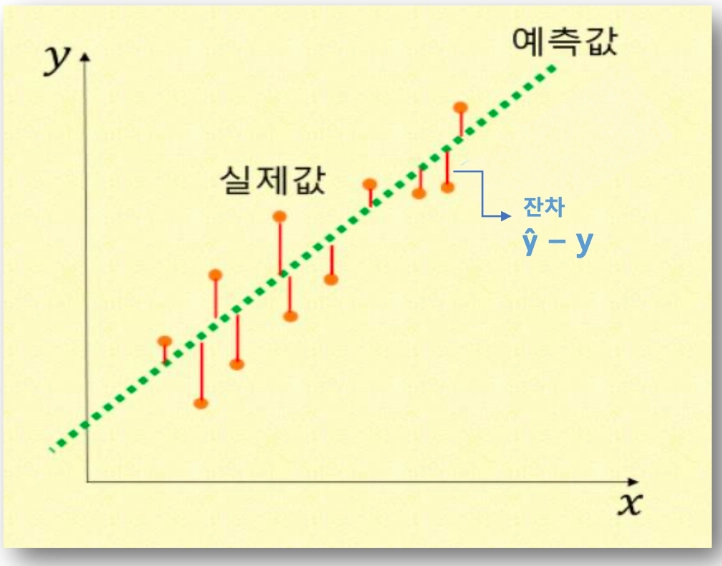

##  다중선형회귀

$$y = W_1x_1 + W_2x_2 + \cdots + W_nx_n + b$$

- 독립변수가 2개 이상인 경우. 독립변수 2개면 3차원 공간에서 회귀선은 **평면**이 됨
- 잔차 = 관측치와 평면 간의 차이. 최소제곱법/경사하강법 모두 사용 가능

- 학점(y) = 중간고사 40% + 기말고사 40% + 과제 20% → 각 40, 40, 20이 회귀계수
- 결국 선형회귀식은 **종속변수 y에 대한 독립변수들의 가중평균**

### 다중선형회귀의 기본 가정 6가지

| 가정 | 내용 | 위배 시 |
|---|---|---|
| 1. 선형성 | 종속변수-설명변수 관계가 선형적 | 당연한 기본가정 |
| 2. 독립성 | 설명변수들이 서로 선형독립 | 위배 시 **다중공선성** (변수 간 강한 상관관계로 영향력 구분 불가) |
| 3. 오차항 평균 0 | $E(\varepsilon_i\|X_i)=0$ | 모델이 항상 실제값보다 치우쳐 예측 = 패턴 미반영 |
| 4. 등분산성 | 오차항 분산이 일정 | 위배 시 **이분산성**(특히 횡단면 자료), 일부 구간만 예측 부정확 |
| 5. 비자기상관 | 오차항 공분산이 항상 0 | 위배 시 **자기상관**(특히 시계열 자료), 반복적 오류 발생 |
| 6. 정규성(선택) | 오차항이 정규분포를 따름 | 위배돼도 계수 추정엔 영향 적으나, p-value 신뢰성 떨어짐 |

- 확인 방법: 선형성(산점도), 독립성(VIF·상관계수), 오차평균0(np.mean(residuals)), 등분산성(잔차 도표화), 자기상관(Durbin-Watson), 정규성(Shapiro-Wilk, Q-Q plot)

**회귀분석 전 vs 후 검증**
- 가정 1(선형성), 2(독립성)는 분석 **전**에도 확인 가능 (X, y 데이터 자체를 봄)
- 가정 3~6(오차항 관련 가정들)은 분석 **후**에만 확인 가능 (오차항은 모델 학습 후에야 계산됨)
- 가정 위배 시 원칙적으로 재분석 필요 → 데이터 분석은 수정과 검증을 반복하는 과정

**완벽히 만족 못 할 때 타협 기준**
- 표본이 충분히 많으면(변수당 10~20개 행 이상) 중심극한정리로 어느 정도 정규성 위배는 넘어가기도 함
- 목적이 **설명**(학술)이면 가정 준수가 중요(p-value 신뢰성) / 목적이 **예측**(비즈니스)이면 가정이 조금 깨져도 MAE·RMSE가 낮으면 사용

##  다중공선성 
- 독립변수 간 강한 상관관계로 회귀모델이 불안정해지는 문제 (예: 주택가격을 예측할때 독립변수: '주택 크기'와 '방 개수')
- 심하면 회귀계수 추정이 부정확해지고 해석력이 떨어짐

**확인 방법**
- **상관계수(r)**: $-1{\le}r{\le}1$, 0이면 무관, `sns.heatmap(df.corr(), annot=True)`나 `pairplot`으로 시각화
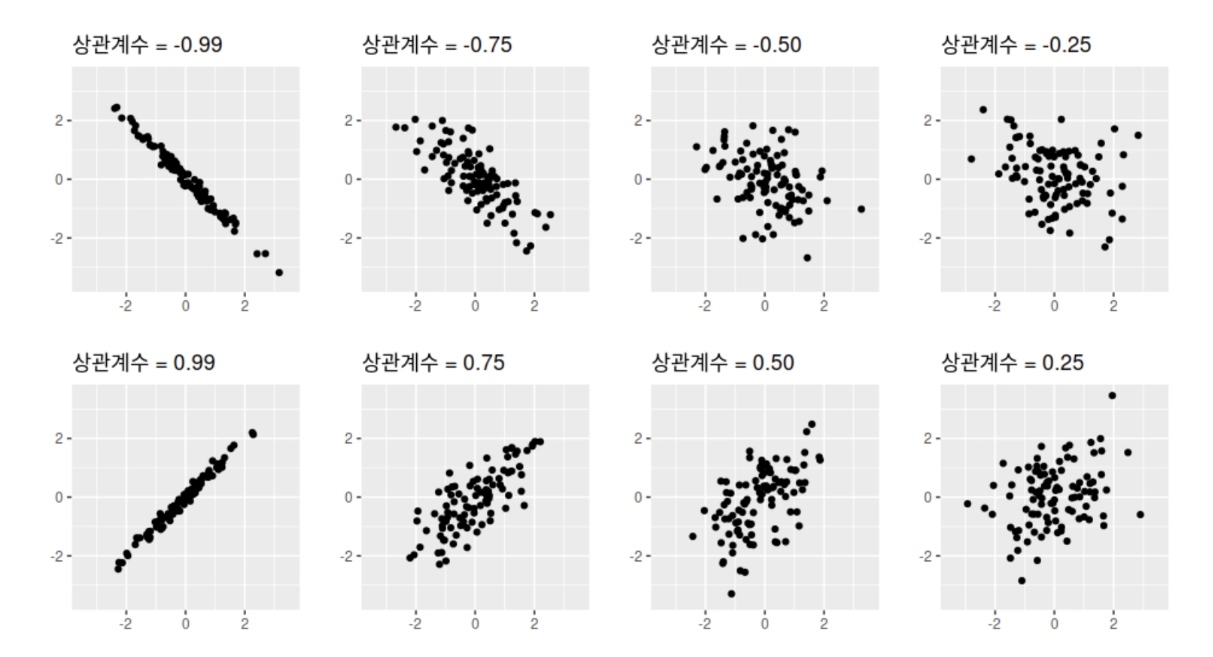
- **VIF지수**: VIF=1(무관), VIF<5(문제없음), VIF>5(주의), VIF>10(심각, 변수 제거 등 조치 필요) — 절대적 기준은 아니고 가이드라인

**대처 방법**
1. 변수 제거
2. 변수 변환(상관 높은 변수 두 개를 하나로 합침. 예: 부부 수입 → 가족수입)
3. 규제선형모델 활용(릿지/라쏘/엘라스틱넷)
4. PCA(주성분 분석): 상관 있는 변수들을 묶어 더 적은 대표 축으로 변환해 차원 축소
   - 과정: 정규화(평균0, 분산1) → 공분산행렬로 주성분(고유벡터) 찾기 → 주성분 축에 투영해 차원 축소 → (선택) 원래 좌표로 복원 가능

##  규제선형모델
- 모델이 학습 데이터에 **과적합**되지 않도록 회귀계수 크기를 조정하는 규제를 가한 모델
- ? 과적합이란 과대적합된 모델은 학습 과정에서 사용한 데이터만 잘 맞추고 그 이외의 데이터는 제대로 맞추지 못한다는, "학습을 너무 많이 해서 실전에는 대응을 못하는" 현상이 발생하게 됩니다
- 회귀계수가 커진다 = 특정 변수에 과하게 의존한다는 뜻
- 비용함수 = 잔차오류 최소화 + 회귀계수 크기 제어, alpha로 균형 조절
  - alpha↑: 규제 강해짐 → 과소적합 쪽 (일반화↑)
  - alpha↓: 선형회귀와 유사 → 과대적합 가능성↑

** 종류**

| | 규제 방식 | 특징 | 비유 |
|---|---|---|---|
| **릿지(Ridge, L2)** | 계수의 **제곱**에 페널티 | 모든 계수 유지하며 크기만 줄임(0은 안 됨) | 큰 기둥은 세게, 작은 기둥은 살살 누르는 망치 |
| **라쏘(Lasso, L1)** | 계수의 **절댓값**에 페널티 | 불필요한 계수를 **0으로 만들어** 변수 제거(변수 선택 기능) | 모든 기둥을 같은 힘으로 눌러 작은 기둥은 사라짐 |
| **엘라스틱넷(Elastic Net)** | L1+L2 동시 | 변수 제거 + 크기 조절 동시 수행, 계산량은 많음 | L1+L2 망치 둘 다 사용 |

- 코드 예:
```python
from sklearn.linear_model import Ridge, Lasso, ElasticNet
ridge = Ridge(alpha=1)
lasso = Lasso(alpha=1, max_iter=10000)
elastic_net = ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000)  
```
- 적절한 alpha는 보통 0.001~100까지 10배씩 늘려가며 train/test score를 비교해 결정 (alpha 작으면 과대적합, 크면 과소적합)

**정리**
- 릿지: 예측변수 많고 다중공선성 있을 때, 변수 선택이 필요 없을 때
- 라쏘: 예측변수 중 일부만 중요할 때, 모델 해석을 단순화하고 싶을 때(단, 수치적으로 덜 안정적)
- 엘라스틱넷: 변수도 많고 다중공선성도 관리하고 싶을 때
- 규제는 계수에 균등한 페널티를 주기 위해 **스케일링이 필수**(StandardScaler, MinMaxScaler 주로 사용)

---

#  모델 평가방법

## 1 시각화
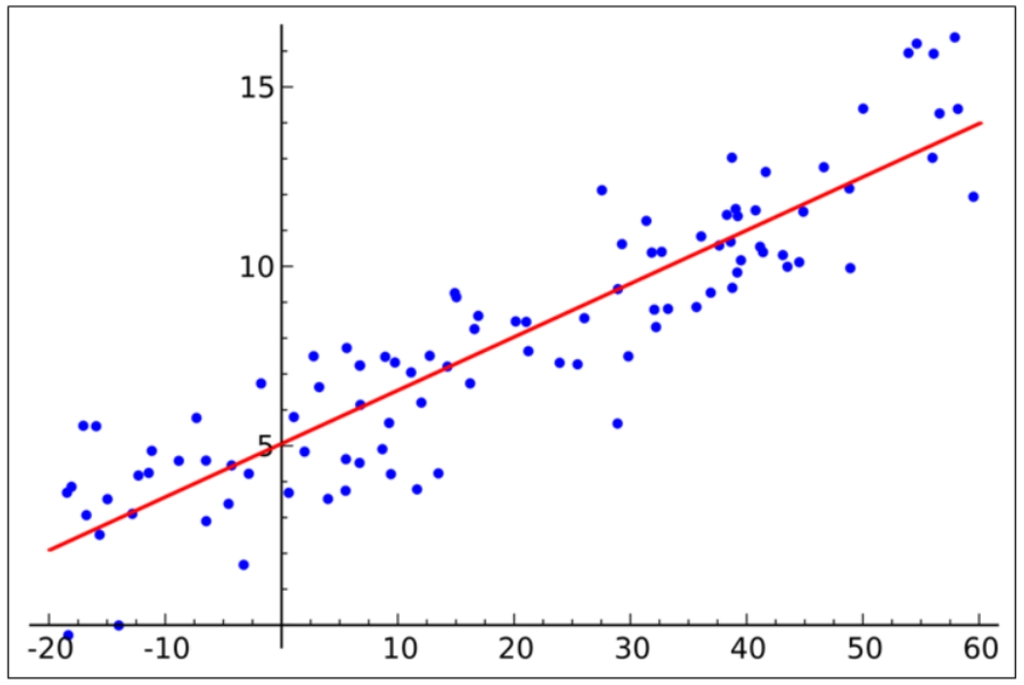
- 회귀선을 데이터와 함께 그려서 확인 가능하지만, 어느 회귀선이 더 나은지 객관적 비교는 어려움 → 통계지표 필요

## 2 통계지표

### (1) 모델 유의성 검정
**F-statistic**: 모델 전체가 유의미한지 검정
- H0: 모든 회귀계수가 0 / H1: 적어도 하나는 0이 아님
- F값이 클수록(=모델이 설명하는 변동/오차의 비율이 클수록) 유의미
- Prob(F-statistic) < 0.05 → 귀무가설 기각 → 모델이 유의미함

**T-statistic**: 개별 변수가 유의미한지 검정
- H0: 해당 변수의 계수가 0 / H1: 0이 아님
- P>|t| < 0.05 → 그 변수는 종속변수에 유의미한 영향을 줌

| | 검정 대상 | 목적 | 기준 |
|---|---|---|---|
| F-검정 | 전체 모델 | 모델 자체가 유의미한지 | p<0.05면 모델이 유의미 |
| T-검정 | 개별 변수 | 특정 변수가 유의미한지 | p<0.05면 그 변수가 유의미 |

### (2) 모델 성능 평가
**결정계수 R²**: 모델이 종속변수의 변동성을 얼마나 설명하는지
- SST(평균으로 예측 시 총 오차) = SSR(모델이 잘 맞힌 부분) + SSE(모델도 못 맞힌 부분)
- $0{\le}R^2{\le}1$, 1에 가까울수록 잘 설명, 0이면 평균으로 예측한 것과 다를 바 없음
- F와 R²는 $F=\dfrac{R^2/k}{(1-R^2)/(n-k-1)}$로 연결되지만, F=모델의 통계적 유의성 / R²=설명력이라는 서로 다른 의미

**조정된 결정계수 Adjusted R²**
- R²는 변수를 추가하면 관련 없는 변수라도 값이 증가하는 단점(***무조건 변수개수가 많아진다고 증가하는건 아님***) → 변수 개수에 페널티를 줘서 보정한 지표
- 변수 추가로 SSE가 충분히 줄면 증가, 거의 안 줄면 오히려 감소

**AIC, BIC(SC)**: 값이 낮을수록 좋은 모델


## 3 성능 평가 지표
- **MSE(평균제곱오차)**: 오차 제곱의 평균, 큰 오차(이상치)에 민감
- **MAE(평균절대오차)**: 오차 절댓값의 평균, 모든 오차를 동일하게 취급(이상치에 덜 민감)
- 모델·데이터 특성과 평가 목적에 따라 선택

## 4 변수 유의성 평가 - T-검정
- H0: 회귀계수=0(영향 없음) / H1: 회귀계수≠0(영향 있음)
- $t=\dfrac{\hat\beta}{SE(\hat\beta)}$ 계산 후 p-value 확인
- p<0.05 → 유의미 / p≥0.05 → 유의미하지 않음
- 예: "창문 개수가 집값에 영향을 준다"는 대립가설로 검정 → p<0.05가 나오면 귀무가설(영향 없다) 기각

---

# 비선형회귀
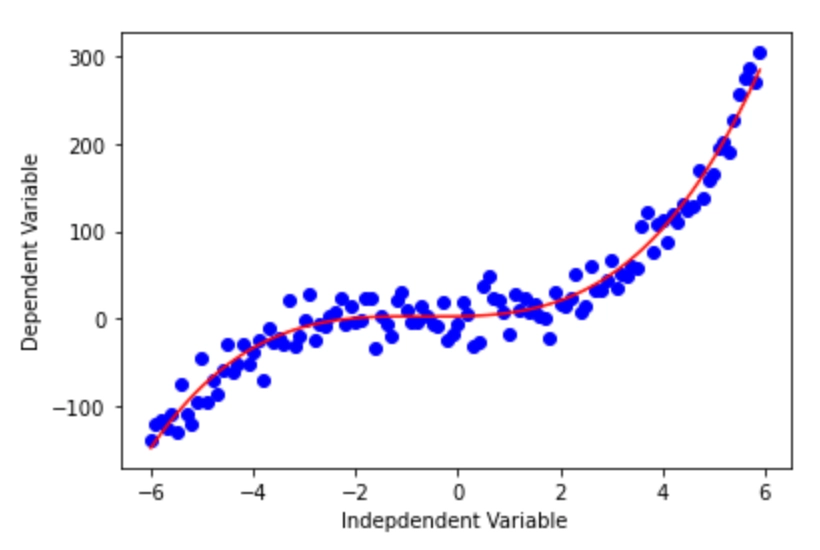

데이터가 선형적이지 않을 땐, 선형이 아닌 식을 사용.

##  다항식 회귀 
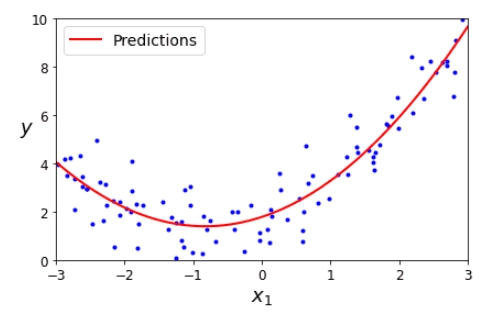
- $Y=a+bX+cX^2+dX^3+\cdots$ 형태로 거듭제곱 항을 추가해 곡선적 특성을 모델링
- 방법: 기존 변수를 다항식으로 확장한 뒤 선형회귀 적용
```python
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)
```
- 장점: 곡선 데이터에 더 잘 맞음 / 단점: 변수를 너무 늘리면 과적합 가능(릿지·라쏘로 방지)
- 적합한 상황: 곡선 패턴, 성장률·감소율이 시간에 따라 변하는 경우

##  지수 회귀 모델 
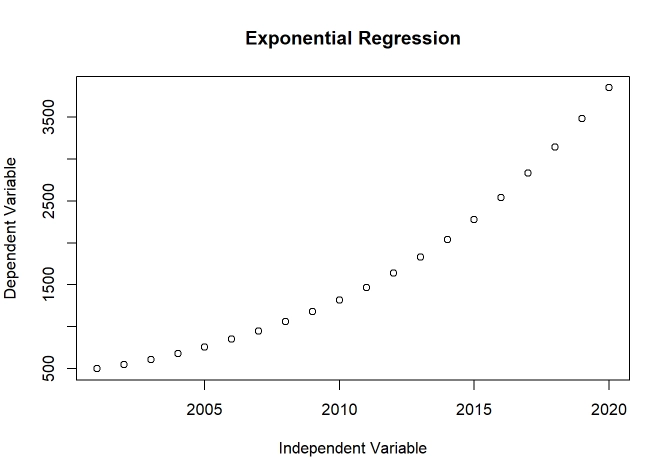
- $Y=ae^{bX}$ 형태. 양변에 로그를 취하면 $\ln Y = \ln a + bX$ → 선형식과 같은 형태가 됨
- 방법: Y에 로그를 취해 선형회귀 적용 → 예측값에 다시 지수함수($e^x$)를 적용해 원래 스케일로 복원
- 적합한 상황: 값이 시간에 따라 지수적으로 증가/감소(기술 발전, 투자 수익률 등)

##  로그 회귀 모델 
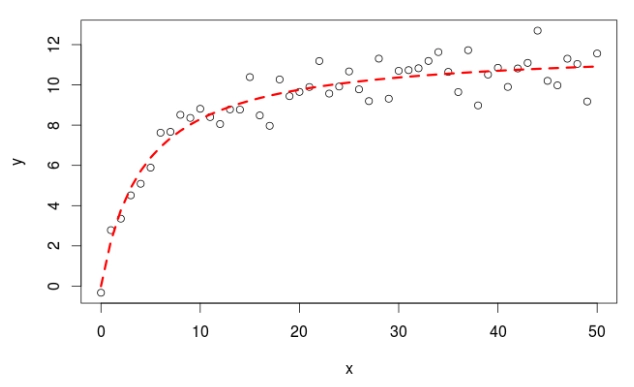
- $Y=a+b\log(X)$ 형태. 독립변수 X에 로그를 취한 뒤 선형회귀 적용(예측값은 그대로 Y라 별도 복원 불필요)
- 적합한 상황: 초기에 빠르게 증가하다 증가율이 점차 줄어드는 패턴(인구 성장, 감염병 확산 등)

##  스플라인 회귀 
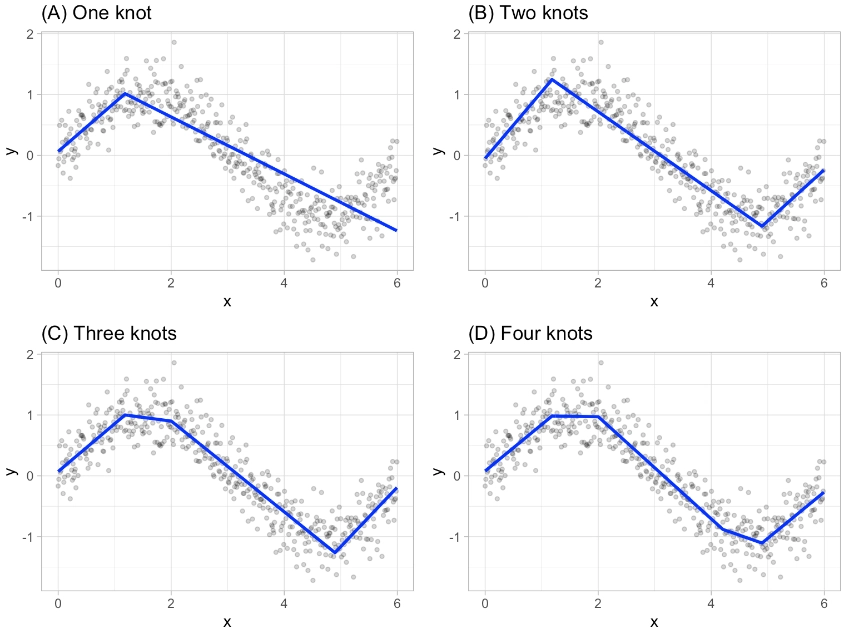
- 데이터를 구간별로 나누고, 각 구간에 다른 회귀식을 적용(구간 경계에서 연속성 유지)
```python
from patsy import dmatrix
X_spline = dmatrix("bs(X, df=5, degree=3, include_intercept=False)", {"X": X}, return_type='dataframe')
```
- 적합한 상황: 구간마다 데이터 패턴이 다를 때(예: 계절별 판매량 변화)